# Stock Volatility Predictor - EDA & Key Finding

Exploratory analysis of the feature set and the central result:
short-horizon realized volatility is only forecastable in proporation to how
much volatility actually moves. Calm years are nearly unpredictable; crisis 
regimes (2020) are highly unpredictable.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ROOT = Path.cwd()
if ROOT.name == "notebooks": # robust whether launched from repo root or notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "src" / "data"))

from data.fetcher import load_config
from train import load_processed, make_fold_data
from evaluate import har_predictions, mincer_zarnowitz, holdout_ticker_index

cfg = load_config()
data = load_processed(cfg)
seq_len = cfg["windowing"]["seq_len"]
tickers = cfg["data"]["tickers"]
feature_names = cfg["features"]["columns"]
sqrt_ann = np.sqrt(cfg["target"]["annualization"])
sns.set_theme(style="whitegrid")

## 1. Data overview & volatility regimes

,rows,start,end,mean_fwd_vol,std_fwd_vol
SPY,2446,2015-04-07,2024-12-20,0.139297,0.115365
AAPL,2446,2015-04-07,2024-12-20,0.242361,0.158876
MSFT,2446,2015-04-07,2024-12-20,0.229627,0.158645
GOOGL,2446,2015-04-07,2024-12-20,0.24404,0.156353


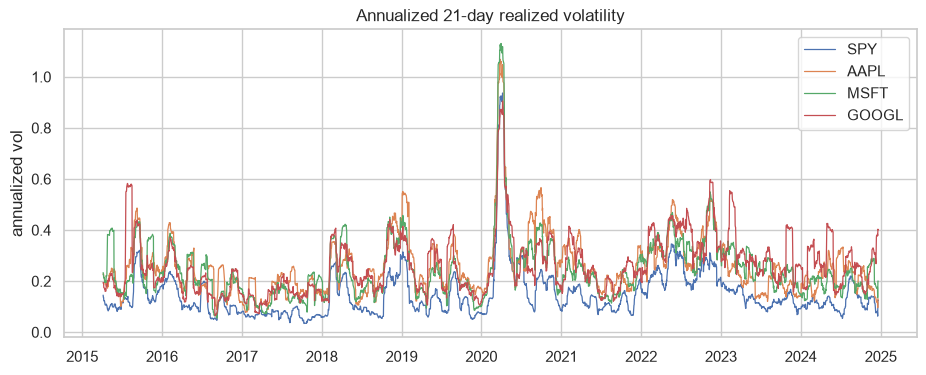

In [2]:
summary = pd.DataFrame({
    t: {
        "rows": len(data[t]["y"]),
        "start": pd.Timestamp(data[t]["dates"].min()).date(),
        "end": pd.Timestamp(data[t]["dates"].max()).date(),
        "mean_fwd_vol": data[t]["y"].mean(),
        "std_fwd_vol": data[t]["y"].std(),
    } for t in tickers
}).T
display(summary)

i_rv21 = feature_names.index("rv_21d")
fig, ax = plt.subplots(figsize=(11, 4))
for t in tickers: 
    ax.plot(pd.to_datetime(data[t]["dates"]), data[t]["X"][:, i_rv21] * sqrt_ann,
            label=t, lw=0.9)
ax.set_title("Annualized 21-day realized volatility")
ax.set_ylabel("annualized vol")
ax.legend()
plt.show()

## 2. Feature correlations (SPY)

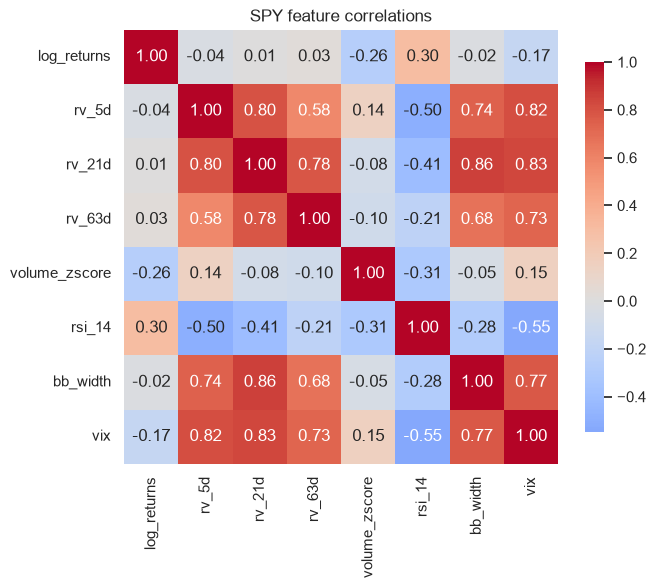

In [3]:
spy = pd.DataFrame(data["SPY"]["X"], columns=feature_names)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(spy.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("SPY feature correlations")
plt.show()

## 3. Key finding - forecastability tracks the vol regime

HAR-RV is re-fit on all data before each calendar year and scored within it
(per-ticker averaged). R^2 is near zero in calm years but jumps to ~0.32 in the 
2020 crash - which is why the single calm-2024 holdout understates the models.

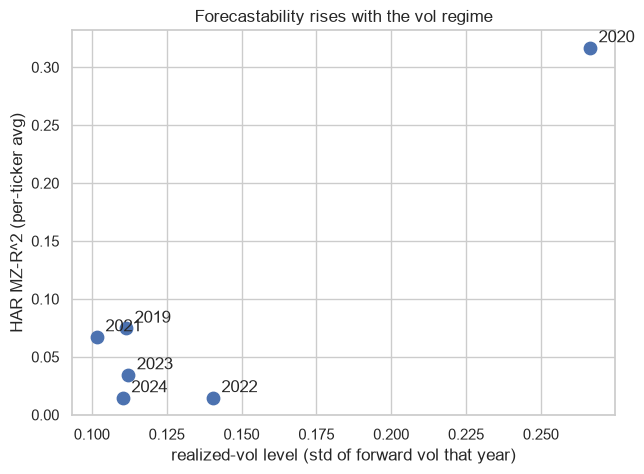

In [4]:
years, ystds, r2s = [], [], []
for year in range(2019, 2025):
    start, end = pd.Timestamp(f"{year}-01-01"), pd.Timestamp(f"{year+1}-01-01")
    _, _, _, y = make_fold_data(data, start, end, seq_len)
    har = har_predictions(data, start, end, seq_len, cfg)
    tix = holdout_ticker_index(data, start, end, seq_len)
    r2 = np.mean([mincer_zarnowitz(y[tix == t], har[tix == t])[0] for t in tickers])
    years.append(year); ystds.append(y.std()); r2s.append(r2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ystds, r2s, s=80)
for x, yv, yr in zip(ystds, r2s, years):
    ax.annotate(str(yr), (x, yv), textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("realized-vol level (std of forward vol that year)")
ax.set_ylabel("HAR MZ-R^2 (per-ticker avg)")
ax.set_title("Forecastability rises with the vol regime")
plt.show()

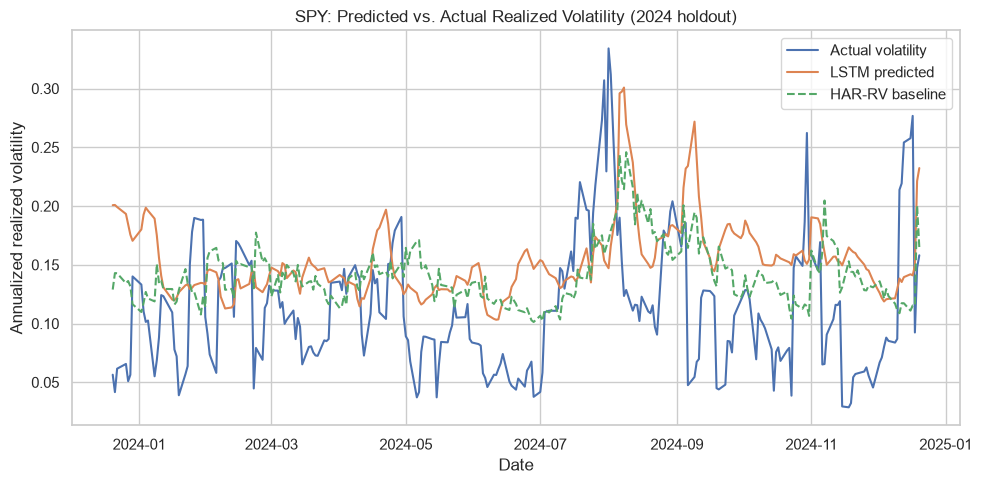

In [5]:
from tensorflow import keras
from evaluate import holdout_window, holdout_ticker_index, har_predictions
from train import make_fold_data

holdout_start, test_end = holdout_window(data, cfg)
tix = holdout_ticker_index(data, holdout_start, test_end, seq_len)
_, _, X_test, y_test = make_fold_data(data, holdout_start, test_end, seq_len)
y_pred_har = har_predictions(data, holdout_start, test_end, seq_len, cfg)

model = keras.models.load_model(ROOT / "models" / "lstm_best.keras")
y_pred = model.predict(X_test, verbose=0).ravel()

def holdout_dates(data, holdout_start, test_end, seq_len):
    """Per-row holdout dates, in the SAME ticker order as make_fold_data/tix."""
    ts_start, ts_end = np.datetime64(holdout_start), np.datetime64(test_end)
    out = []
    for d in data.values():
        label_dates = d["dates"][seq_len - 1:]
        is_test = (label_dates >= ts_start) & (label_dates < ts_end)
        out.append(pd.to_datetime(label_dates[is_test]))
    return np.concatenate(out)

dates_test = holdout_dates(data, holdout_start, test_end, seq_len)

ticker = "SPY"
mask = tix == ticker

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dates_test[mask], y_test[mask], label="Actual volatility")
ax.plot(dates_test[mask], y_pred[mask], label="LSTM predicted")
ax.plot(dates_test[mask], y_pred_har[mask], label="HAR-RV baseline", linestyle="--")
ax.legend()
ax.set_title(f"{ticker}: Predicted vs. Actual Realized Volatility (2024 holdout)")
ax.set_xlabel("Date"); ax.set_ylabel("Annualized realized volatility")
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "results_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
def qlike(y_true, y_pred):
    return np.mean(y_pred/y_true - np.log(y_pred/y_true) - 1)

from sklearn.metrics import r2_score

print("LSTM QLIKE:", qlike(y_test, y_pred), " R2:", r2_score(y_test, y_pred))
print("HAR-RV QLIKE:", qlike(y_test, y_pred_har), " R2:", r2_score(y_test, y_pred_har))

LSTM QLIKE: 0.20489587  R2: 0.04865759611129761
HAR-RV QLIKE: 0.19449402453830525  R2: -0.03175623356131485
